In [1]:
import pandas as pd
import shap

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier

In [2]:
df = pd.read_csv("gig_worker_credit_data_v2.csv")

In [3]:
worker_encoder = LabelEncoder()
risk_encoder = LabelEncoder()

df["worker_type"] = worker_encoder.fit_transform(
    df["worker_type"]
)

df["risk_category"] = risk_encoder.fit_transform(
    df["risk_category"]
)

In [4]:
X = df.drop(
    ["risk_category",
     "financial_health_score"],
    axis=1
)

y = df["risk_category"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [8]:
explainer = shap.TreeExplainer(
    xgb_model
)

shap_values = explainer.shap_values(
    X_test
)

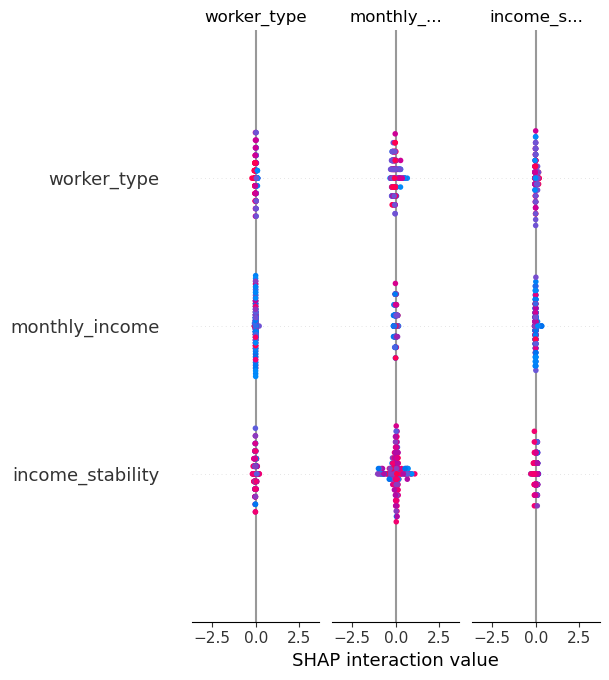

In [9]:
shap.summary_plot(
    shap_values,
    X_test
)

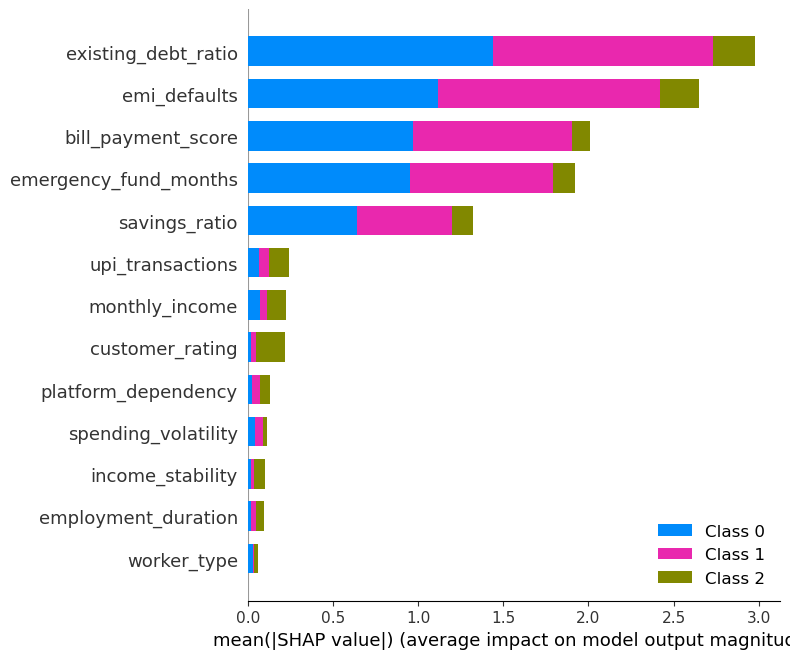

In [10]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [11]:
sample_index = 0

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_index],
        feature_names=X_test.columns
    )
)

ValueError: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (13, 3)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.

In [12]:
print(type(shap_values))

<class 'numpy.ndarray'>


In [13]:
print(shap_values.shape)

(200, 13, 3)


In [14]:
import joblib

joblib.dump(
    xgb_model,
    "fairscore_xgb_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [15]:
import os

print(os.getcwd())

C:\Users\Niraja


In [16]:
import os

print(os.listdir())

['.anaconda', '.arduinoIDE', '.conda', '.continuum', '.dbus-keyrings', '.expo', '.gitconfig', '.idea', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.node_repl_history', '.ssh', '.thumbnails', '.VirtualBox', '.virtual_documents', '.vscode', '.vscode-shared', '.Xilinx', '.xinstall', '03_model_training.ipynb', '04_shap_explainability.ipynb', 'adcexp3.grc', 'anaconda3', 'AppData', 'Application Data', 'audio.grc', 'audio.py', 'Bank.java', 'calculating area.html', 'Contacts', 'Cookies', 'Customer.java', 'c_exp1.grc', 'c_exp1.py', 'dataset_creation.ipynb', 'Documents', 'Downloads', 'eda.ipynb', 'fairscore_xgb_model.pkl', 'Favorites', 'file.py', 'fm.grc', 'fm.py', 'Forensics', 'frequencymodulation.grc', 'gig_worker_credit_data.csv', 'gig_worker_credit_data_v2.csv', 'html', 'IdeaProjects', 'index.html', 'IntelGraphicsProfiles', 'javascript in html.html', 'Links', 'Local Settings', 'Music', 'My Documents', 'naturalnumbers.c', 'NetHood', 'new.css', 'Niraja.iml', 'NTUSER.DAT', 'nt